# WebSight → формат контракта (drafting)

Конвертер: берёт срез **WebSight v0.2** (`HuggingFaceM4/WebSight`, Tailwind) и складывает его
в датасет по **контракту `SFT/DATA_FORMAT_CONTRACT.md`** (схема §2, `save_to_disk`, картинки как
`Image()`-байты), готовый к `load_from_disk` на SFT-стороне. Задача — `task_type="drafting"`
(скриншот → HTML). Лёгкий v0.1-срез (`mrm8488/WebSight_70k`, plain CSS) оставлен как отладочный
вариант в конфиге.

**Гигиена, включённая в пилот:**
- **Единый размер скриншота** (`TARGET_SIZE`, `SIZE_MODE`) — контракт §4a. По умолчанию `filter`
  (оставляем только нативный целевой размер, без порчи соответствия код↔картинка).
- **Отсев висячих `<img>`** (`DROP_IMG`) — у WebSight относительные `src` (`logo.png`…) битые;
  до плейсхолдеров+ре-рендера честнее выкинуть такие сэмплы.
- Дедуп по SHA1 HTML; фильтр по бюджету токенов (`MAX_TOKENS`, через `token_len.count_tokens`).
- **Декотаминация** по блоклисту доменов (`DECONTAM_DOMAINS`) и **near-dup** картинок по average-hash (`NEAR_DUP_HAMMING`) — для синтетики WebSight обычно почти no-op, нужны для реальных датасетов.

**Осознанно отложено (не блокирует пилот):**
- **Серые плейсхолдеры** (`APPLY_PLACEHOLDERS=False`). Включать только вместе с **ре-рендером**
  скриншота из placeholder-версии (иначе исходный скриншот и код разойдутся). Ре-рендер = Этап 2.
- **Tailwind precompile** (Tailwind CLI → статический CSS в `<style>`) — обязателен для v0.2, но
  это отдельная реализация Этапа 1.
- **Декотаминация доменов**, near-dup по перцептивному хешу картинки — следующая итерация.

Цель шага — сквозной пайплайн end-to-end и первый LoRA у SFT-трека.

## 1. Импорты и конфиг

In [ ]:
import os, sys, hashlib
from datasets import load_dataset, Dataset, Features, Image, Value, Sequence, load_from_disk
from bs4 import BeautifulSoup

# --- источник ---
DATASET = "HuggingFaceM4/WebSight"   # v0.2 (~2M): Tailwind; поля image (PIL) + text (HTML)
                                     # лёгкий срез для отладки: "mrm8488/WebSight_70k" (v0.1, plain CSS — НЕ Tailwind)
SPLIT        = "train"
TARGET_COUNT = 500     # сколько ПРИНЯТЫХ сэмплов собрать (стрим идёт, пока не наберём; при OOM на save — уменьшить)
MAX_SCAN     = 20000   # предел просмотренных сырых примеров (защита от бесконечного стрима)

# --- выход ---
OUT_DIR = os.path.abspath("./websight_drafting_pilot")

# --- гигиена: размер скриншота (контракт §4a — один фиксированный размер) ---
TARGET_SIZE = None          # None = автоопределение доминирующего нативного размера из выборки (безопасно,
                            # не выкидывает всё). Для точного согласования с eval задать явно, напр. (1280,720).
SIZE_MODE   = "filter"      # "filter" — оставлять только сэмплы с TARGET_SIZE (плюрализм native, без порчи код↔скрин);
                            # "pad"    — привести к TARGET_SIZE crop/pad (осторожно: обрезка full-page рвёт соответствие)

# --- гигиена: картинки / плейсхолдеры ---
APPLY_PLACEHOLDERS = False  # True → серые плейсхолдеры + ре-рендер скрина (нужен playwright + chromium)
DROP_IMG           = True   # без плейсхолдеров+ре-рендера — выкидывать сэмплы с <img> (битые относительные src)

# --- гигиена: бюджет токенов ---
MAX_TOKENS   = None                        # напр. 768; None = без фильтра. Точный фильтр токенайзером Qwen
TOKENIZER_ID = "Qwen/Qwen3-VL-8B-Instruct" # (id уточнить, когда SFT зафиксирует модель)

IMAGE_TOKEN_BUDGET = 0     # визуальные токены на картинку — заложить после согласования разрешения с eval

# --- гигиена: декотаминация (домены eval-датасетов никогда в train) ---
DECONTAM_DOMAINS = set()   # блоклист доменов eval-бенчей; для синтетики WebSight пусто (реальных доменов нет),
                           # заполнять при подключении реальных датасетов (WebCode2M/WebUI)

# --- гигиена: near-dup картинок (average-hash, расстояние Хэмминга) ---
NEAR_DUP_HAMMING = None     # None = выкл; напр. 4 — резать почти-дубли картинок (O(n^2), для больших N дорого)

# --- боевой self-contained (хуки, требуют внешнего тулинга — см. websight_to_contract.md) ---
PRECOMPILE_TAILWIND = False # True → CDN-Tailwind вкомпилировать в <style> (нужен pip install pytailwindcss)

HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

_tokenizer = None
if MAX_TOKENS is not None:
    sys.path.append(os.path.abspath("analysis"))   # переиспользуем count_tokens из token_len.py
    from token_len import count_tokens
    from transformers import AutoTokenizer
    _tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)

print("out:", OUT_DIR, "| source:", DATASET)

## 2. Конвенция плейсхолдеров (идентична eval-треку)

In [ ]:
# ВАЖНО: ровно как в Evaluation/Experiments.ipynb. Менять только синхронно с eval.
PLACEHOLDER_CLASSES = ["bg-gray-300", "w-full", "h-48", "rounded"]
PLACEHOLDER_STYLE = "background-color:#d1d5db;width:100%;height:12rem;border-radius:0.5rem;display:block;"

def replace_images_with_placeholder(html_text):
    soup = BeautifulSoup(html_text, "html.parser")
    n = 0
    for img in soup.find_all("img"):
        div = soup.new_tag("div")
        div["class"] = PLACEHOLDER_CLASSES
        div["style"] = PLACEHOLDER_STYLE
        img.replace_with(div)
        n += 1
    return str(soup), n


from PIL import Image as PILImage

def fit_to_size(img, size):
    """Привести скриншот к фиксированному (W,H): паддинг белым + обрезка снизу-справа.
    ВНИМАНИЕ: обрезка full-page скриншота рвёт соответствие код↔картинка — для честного
    пилота предпочтителен SIZE_MODE='filter'."""
    tw, th = size
    img = img.convert("RGB")
    canvas = PILImage.new("RGB", size, (255, 255, 255))
    canvas.paste(img.crop((0, 0, min(img.width, tw), min(img.height, th))), (0, 0))
    return canvas

# --- декотаминация: домены, на которые ссылается страница ---
from urllib.parse import urlparse
def page_domains(html_text):
    doms = set()
    soup = BeautifulSoup(html_text, "html.parser")
    for tag in soup.find_all(["a", "img", "link", "script", "source"]):
        url = (tag.get("href") or tag.get("src") or "").strip()
        if not url or url.startswith(("#", "mailto:", "tel:", "javascript:", "data:")):
            continue
        t = "http:" + url if url.startswith("//") else url
        net = urlparse(t).netloc.lower()
        if net:
            doms.add(net)
    return doms

# --- near-dup: average-hash картинки (чистый PIL, без внешних зависимостей) ---
def ahash(img, size=8):
    g = img.convert("L").resize((size, size))
    px = list(g.getdata()); avg = sum(px) / len(px)
    return sum(1 << i for i, p in enumerate(px) if p > avg)
def _hamming(a, b):
    return bin(a ^ b).count("1")

# --- Tailwind precompile: CDN -> статический <style> (self-contained) ---
import re as _re2, subprocess as _sp, tempfile as _tmp, os as _os, shutil as _sh

_TW_CDN_RE = _re2.compile(r'<script\b[^>]*tailwind[^>]*>\s*</script>|<link\b[^>]*tailwind[^>]*>', _re2.I)

def precompile_tailwind(html_text):
    """CDN-Tailwind -> инлайновый <style> (компилирует только используемые классы).
    Без Node: pip install pytailwindcss  (даёт бинарь `tailwindcss`).
    Медленно (subprocess на страницу). НЕ протестировано в песочнице — проверить локально."""
    tw = _sh.which("tailwindcss")
    if tw is None:
        raise RuntimeError("нужен tailwindcss CLI: pip install pytailwindcss (standalone, без Node)")
    clean = _TW_CDN_RE.sub("", html_text)            # убрать CDN-подключение Tailwind
    with _tmp.TemporaryDirectory() as t:
        with open(_os.path.join(t, "page.html"), "w", encoding="utf-8") as f: f.write(clean)
        with open(_os.path.join(t, "in.css"), "w") as f:
            f.write("@tailwind base;\n@tailwind components;\n@tailwind utilities;")
        with open(_os.path.join(t, "tailwind.config.js"), "w") as f:
            f.write("module.exports = { content: ['page.html'] };")
        _sp.run([tw, "-c", "tailwind.config.js", "-i", "in.css", "-o", "out.css", "--minify"],
                cwd=t, check=True, capture_output=True, text=True)
        with open(_os.path.join(t, "out.css"), encoding="utf-8") as f: css = f.read()
    style = f"<style>{css}</style>"
    low = clean.lower()
    if "</head>" in low:
        i = low.index("</head>"); return clean[:i] + style + clean[i:]
    return "<!doctype html><html><head><meta charset='utf-8'>" + style + "</head><body>" + clean + "</body></html>"


# --- Ре-рендер скриншота из HTML (Playwright, переиспользуем браузер) ---
_PW = {"pw": None, "browser": None}

def _pw_browser():
    if _PW["browser"] is None:
        from playwright.sync_api import sync_playwright
        _PW["pw"] = sync_playwright().start()
        _PW["browser"] = _PW["pw"].chromium.launch()
    return _PW["browser"]

def rerender_from_html(html_text, size):
    """Отрендерить HTML в скриншот size=(W,H) — чтобы картинка следовала за кодом
    (нужно после плейсхолдеров). Установка: pip install playwright ; playwright install chromium.
    Если Tailwind НЕ предкомпилирован — рендер тянет CDN (нужна сеть). НЕ протестировано в песочнице."""
    import io
    w, h = size
    page = _pw_browser().new_page(viewport={"width": w, "height": h}, device_scale_factor=1)
    try:
        page.set_content(html_text, wait_until="networkidle")
        png = page.screenshot(clip={"x": 0, "y": 0, "width": w, "height": h})
    finally:
        page.close()
    return PILImage.open(io.BytesIO(png)).convert("RGB")

def close_renderer():
    if _PW["browser"] is not None:
        _PW["browser"].close(); _PW["pw"].stop(); _PW["browser"] = _PW["pw"] = None


## 3. Схема сэмпла (контракт §2)

In [19]:
# Единая схема под 3 задачи; для drafting заполнены только images + target_html.
FEATURES = Features({
    "task_type":    Value("string"),
    "images":       Sequence(Image()),   # встроенные байты, НЕ пути к файлам
    "current_html": Value("string"),
    "target_html":  Value("string"),
    "instruction":  Value("string"),
})

## 4. Проба размера + фабрика стрима

In [20]:
import itertools
from collections import Counter

def fresh_stream():
    return load_dataset(DATASET, split=SPLIT, streaming=True)

# Авто-размер (контракт §4a): пробегаем первые PROBE примеров, копим ТОЛЬКО размеры (не картинки в память).
PROBE = 400
if TARGET_SIZE is None:
    _sizes = Counter()
    for r in itertools.islice(fresh_stream(), PROBE):
        im = r.get("image")
        if im is not None:
            _sizes[im.size] += 1
    if not _sizes:
        raise ValueError("в пробе нет картинок — проверь источник/поле image")
    TARGET_SIZE = _sizes.most_common(1)[0][0]
    print(f"авто TARGET_SIZE = {TARGET_SIZE} "
          f"(доминирует {_sizes[TARGET_SIZE]}/{sum(_sizes.values())} в пробе, размеров: {len(_sizes)})")

print("ключи примера:", list(next(iter(fresh_stream())).keys()))

авто TARGET_SIZE = (2560, 1440) (доминирует 271/400 в пробе, размеров: 102)
ключи примера: ['image', 'text', 'llm_generated_idea']


## 5. Сборка сэмплов + базовая гигиена (дедуп, отсев пустых)

In [ ]:
rows, seen, _img_hashes = [], set(), []
skipped_empty = skipped_dup = skipped_img = skipped_size = skipped_long = 0
skipped_decontam = skipped_neardup = 0
scanned = 0

for r in fresh_stream():                       # ленивый стрим — не грузим весь датасет в память
    if len(rows) >= TARGET_COUNT or scanned >= MAX_SCAN:
        break
    scanned += 1
    html = (r.get("text") or r.get("html") or "").strip()
    img  = r.get("image")
    if not html or img is None:
        skipped_empty += 1
        continue

    # декотаминация: домены eval-датасетов никогда в train
    if DECONTAM_DOMAINS and (page_domains(html) & DECONTAM_DOMAINS):
        skipped_decontam += 1
        continue

    # размер скриншота → один фиксированный (контракт §4a)
    if SIZE_MODE == "filter":
        if img.size != TARGET_SIZE:
            skipped_size += 1
            continue
    elif SIZE_MODE == "pad":
        img = fit_to_size(img, TARGET_SIZE)

    # near-dup картинок (average-hash)
    if NEAR_DUP_HAMMING is not None:
        _h = ahash(img)
        if any(_hamming(_h, _o) <= NEAR_DUP_HAMMING for _o in _img_hashes):
            skipped_neardup += 1
            continue
        _img_hashes.append(_h)

    # картинки в HTML: плейсхолдеры (если включены) ИЛИ отсев битых <img>
    if APPLY_PLACEHOLDERS:
        html, _ = replace_images_with_placeholder(html)
    elif DROP_IMG and BeautifulSoup(html, "html.parser").find("img") is not None:
        skipped_img += 1
        continue

    # self-contained: Tailwind precompile (CDN -> статический <style>)
    if PRECOMPILE_TAILWIND:
        html = precompile_tailwind(html)

    # ре-рендер: плейсхолдеры изменили вид → скриншот перерисовать из ФИНАЛЬНОГО html
    # (precompile уже вкомпилировал CSS → рендер офлайн, детерминированно)
    if APPLY_PLACEHOLDERS:
        img = rerender_from_html(html, TARGET_SIZE)

    # бюджет токенов
    if MAX_TOKENS is not None and count_tokens(html, _tokenizer) > MAX_TOKENS:
        skipped_long += 1
        continue

    h = hashlib.sha1(html.encode("utf-8")).hexdigest()
    if h in seen:
        skipped_dup += 1
        continue
    seen.add(h)

    rows.append({
        "task_type":    "drafting",
        "images":       [img.convert("RGB")],
        "current_html": "",
        "target_html":  html,
        "instruction":  "",
    })

print(f"собрано: {len(rows)}/{TARGET_COUNT} (просмотрено {scanned}) | пропущено: "
      f"пустых={skipped_empty}, размер!={skipped_size}, <img>={skipped_img}, "
      f"длинных={skipped_long}, дублей={skipped_dup}, decontam={skipped_decontam}, near-dup={skipped_neardup}")

## 6. Сохранение на диск

In [22]:
assert rows, ("rows пуст — все сэмплы отфильтрованы. Проверь SIZE_MODE/TARGET_SIZE "
               "(при 'filter' native-размеры могут не совпасть — попробуй SIZE_MODE='pad'), "
               "DROP_IMG, MAX_TOKENS.")
ds = Dataset.from_list(rows, features=FEATURES)
ds.save_to_disk(OUT_DIR)
print("сохранено:", OUT_DIR)

Saving the dataset (1/1 shards): 100%|██████████| 500/500 [00:00<00:00, 1009.06 examples/s]

сохранено: /Users/vyacheslav/Screenshot2Code/ScreenShot2Code/Data/websight_drafting_pilot


## 7. Приёмка (контракт §6)

сэмплов с Tailwind-подобными классами: 500/500
self-contained: 0/500 (внешних URL: 500, из них Tailwind-CDN: 500)
rows: 500 | размер скриншота: (2560, 1440)
target_html head: <html>
<link href="https://cdn.jsdelivr.net/npm/tailwindcss@2.2.19/dist/tailwind
⚠ ЧАСТИЧНО: схема §2, размер §4a, отсев <img> — OK; но HTML НЕ self-contained (§4.1/§4.2) — нужен Tailwind-precompile до отдачи в eval. Для смоук-пилота допустимо.


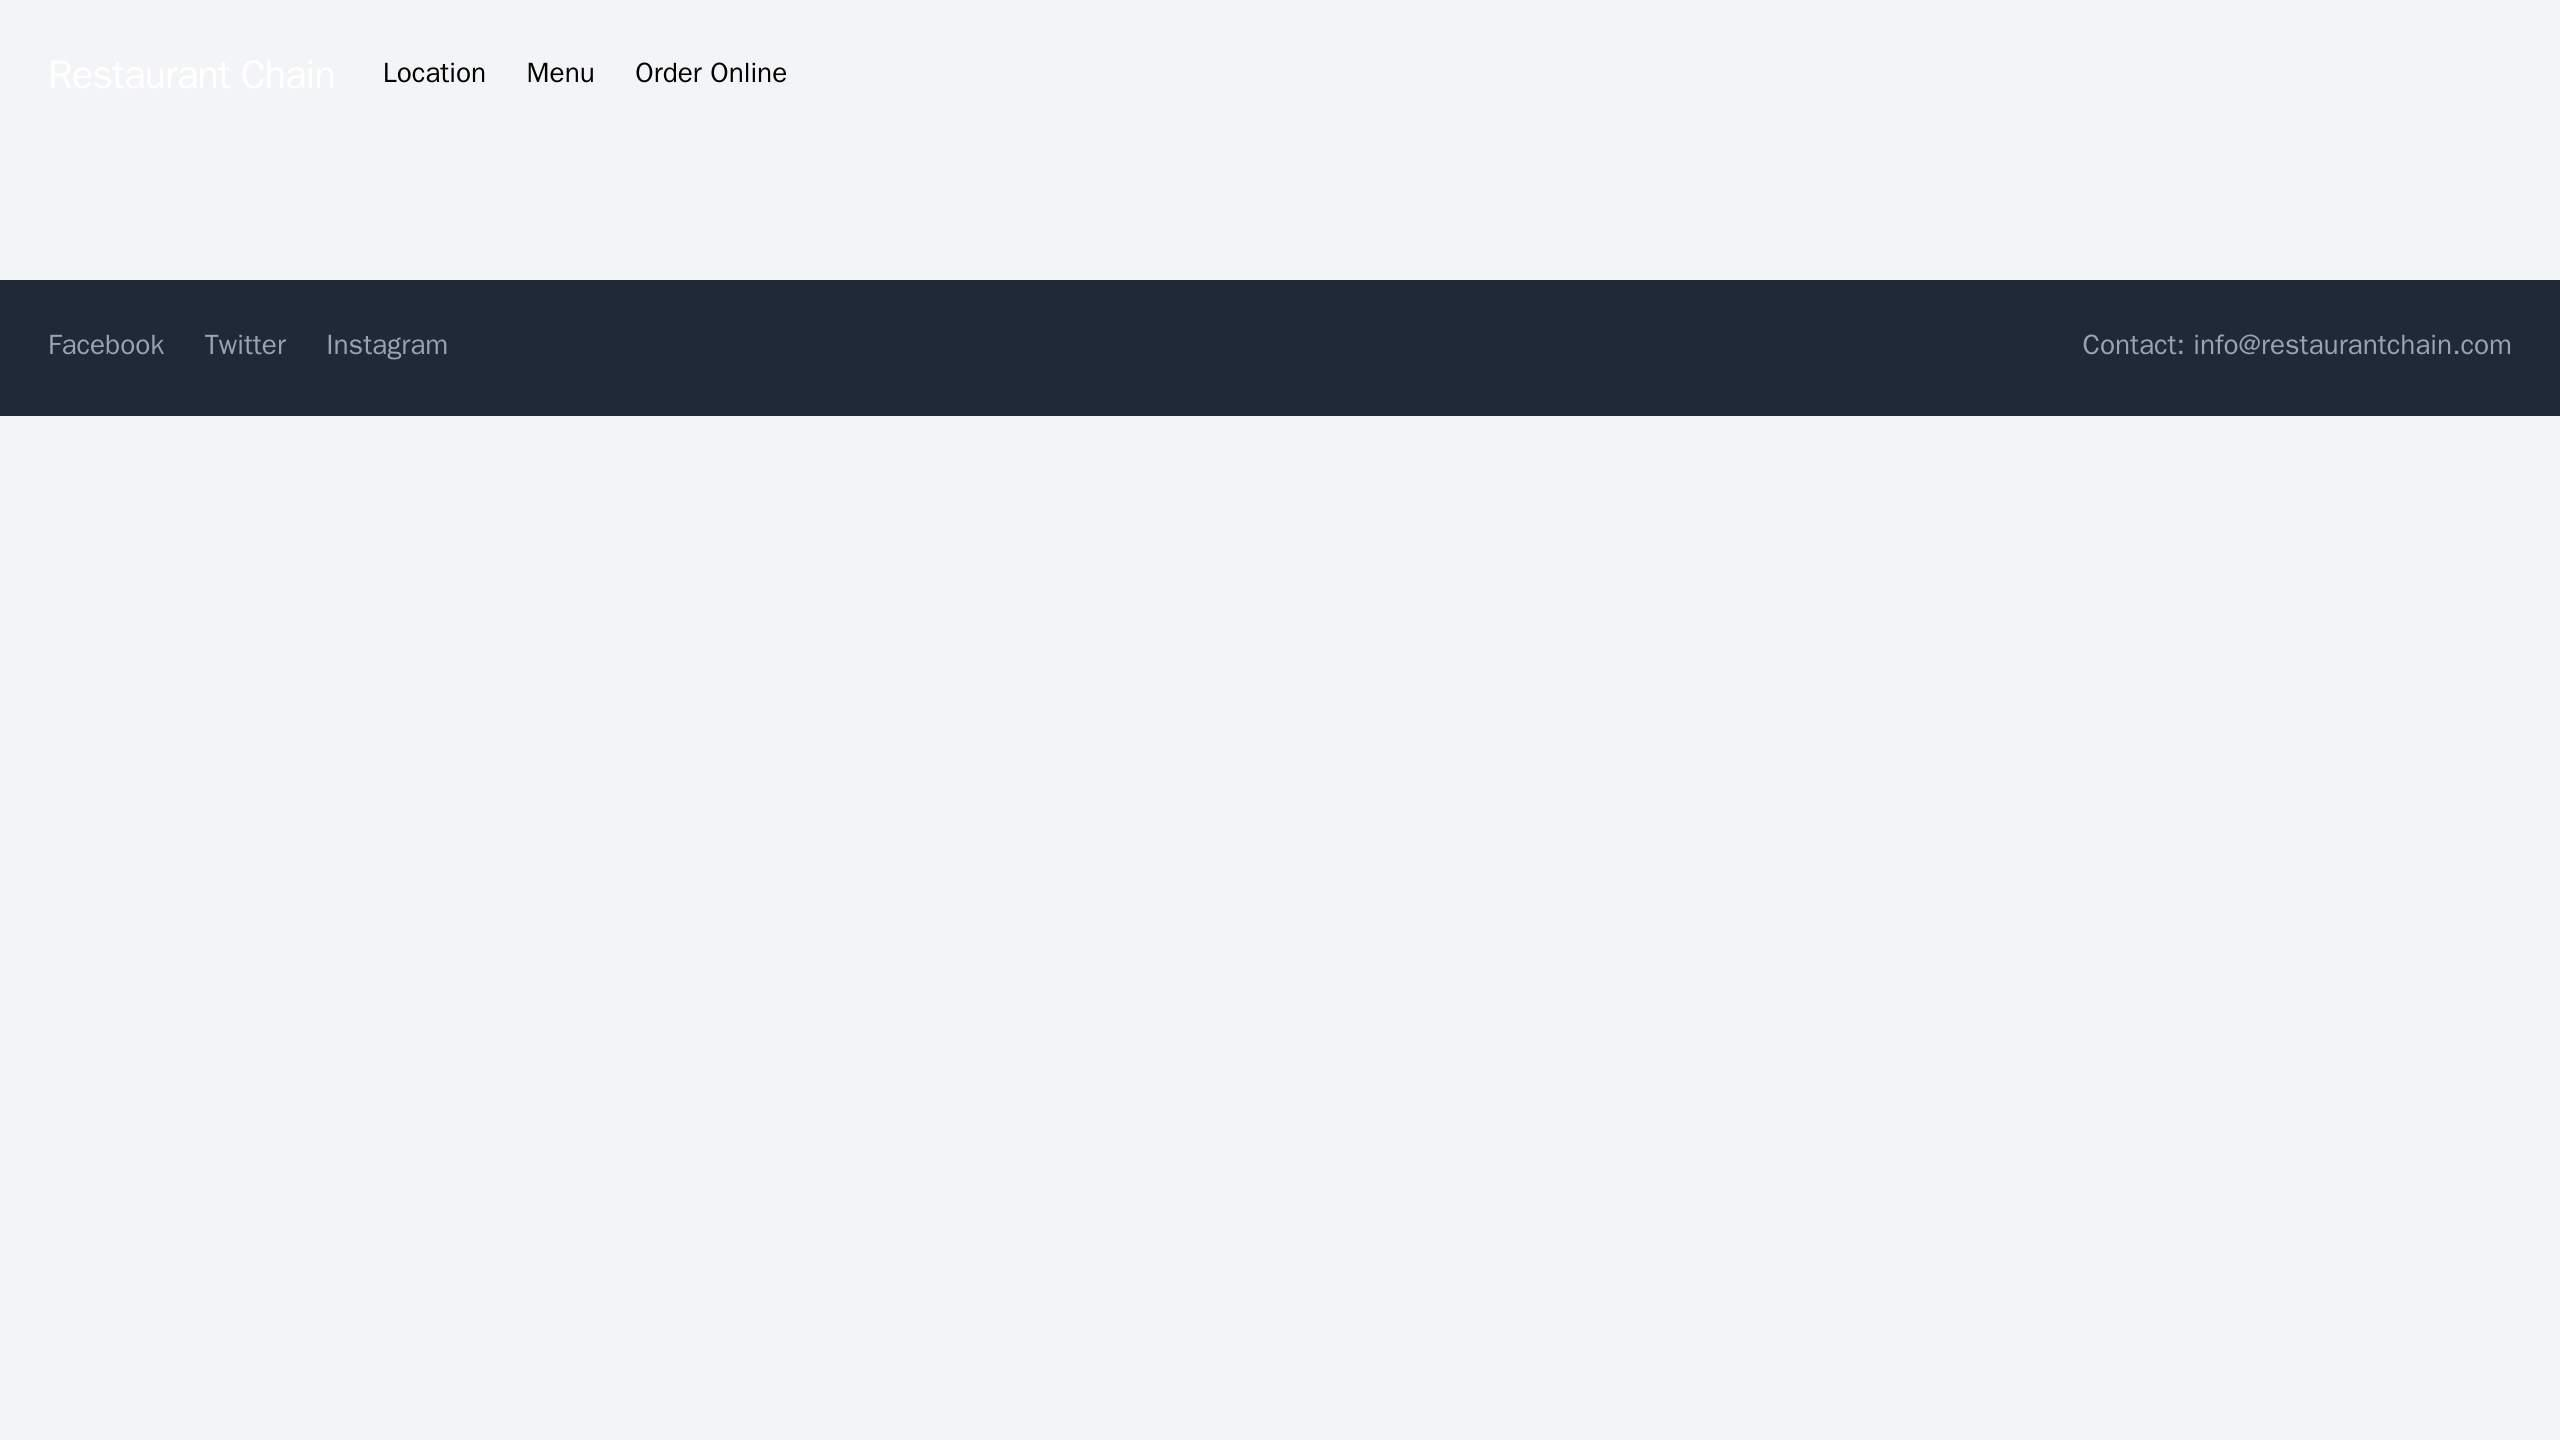

In [23]:
ds2 = load_from_disk(OUT_DIR)
assert ds2.column_names == ["task_type","images","current_html","target_html","instruction"], ds2.column_names

# --- приёмка по контракту §6 ---
sizes = {tuple(s["images"][0].size) for s in ds2}
assert len(sizes) == 1, f"скриншоты разного размера: {sizes}"          # §4a: один фиксированный размер
assert sizes == {TARGET_SIZE}, f"размер {sizes} != TARGET_SIZE {TARGET_SIZE}"

if not APPLY_PLACEHOLDERS:
    n_img = sum("<img" in s["target_html"].lower() for s in ds2)
    assert n_img == 0, f"остались висячие <img> в {n_img} сэмплах (ожидался DROP_IMG=True)"

s = ds2[0]
assert s["task_type"] == "drafting"
assert len(s["images"]) == 1 and s["images"][0].size
assert s["target_html"] and s["current_html"] == "" and s["instruction"] == ""

# Tailwind ожидается на v0.2 (не на v0.1-срезе) — мягкая проверка, не assert
import re as _re
n_tw = sum(bool(_re.search(r'class="[^"]*(flex|grid|bg-|text-|p-\d|w-full)', x["target_html"])) for x in ds2)
print(f"сэмплов с Tailwind-подобными классами: {n_tw}/{len(ds2)}"
      + ("  (! мало — источник v0.1 plain CSS?)" if n_tw < len(ds2) * 0.5 else ""))

# Self-contained (контракт §4.1/§4.2): без внешних URL и без Tailwind через CDN.
# WebSight v0.2 «как есть» тянет Tailwind с CDN — это НЕ self-contained, закрывается
# только Tailwind-precompile (отложенный TODO). Пока — честное предупреждение, не assert.
n_ext = sum(bool(_re.search(r'(src|href)="https?://', x["target_html"])) for x in ds2)
n_cdn = sum(bool(_re.search(r'cdn[^"]*tailwind', x["target_html"], _re.I)) for x in ds2)
self_contained = (n_ext == 0)
print(f"self-contained: {len(ds2) - n_ext}/{len(ds2)} (внешних URL: {n_ext}, из них Tailwind-CDN: {n_cdn})")

print("rows:", len(ds2), "| размер скриншота:", next(iter(sizes)))
print("target_html head:", s["target_html"][:80])
if self_contained:
    print("OK — соответствует контракту (drafting): схема + размер + self-contained")
else:
    print("⚠ ЧАСТИЧНО: схема §2, размер §4a, отсев <img> — OK; но HTML НЕ self-contained "
          "(§4.1/§4.2) — нужен Tailwind-precompile до отдачи в eval. Для смоук-пилота допустимо.")
s["images"][0]   # покажет скриншот прямо в ноутбуке

## 8. Токенный отчёт и передача SFT

In [24]:
# Токены произведённого набора → рекомендуемый max_length для SFT
import sys, os
sys.path.append(os.path.abspath("analysis"))   # count_tokens из token_len.py
from token_len import count_tokens, recommend_max_length
from transformers import AutoTokenizer

_tok = AutoTokenizer.from_pretrained(TOKENIZER_ID)
_lens = sorted(count_tokens(s["target_html"], _tok) for s in ds2)
_med = _lens[len(_lens)//2]
_p99 = _lens[min(len(_lens)-1, int(len(_lens)*0.99))]
MAX_LENGTH_CODE = recommend_max_length(_lens, quantile=0.99, round_to=64, image_token_budget=IMAGE_TOKEN_BUDGET)
print(f"токены target_html (n={len(_lens)}): median={_med}, p99={_p99}, max={_lens[-1]}")
print(f"рекомендуемый max_length по коду (p99 -> округл. 64): {MAX_LENGTH_CODE}  (+ бюджет картинки)")

токены target_html (n=500): median=420, p99=856, max=1206
рекомендуемый max_length по коду (p99 -> округл. 64): 768  (+ бюджет картинки)


In [25]:
# HANDOFF — памятка для SFT-трека (числа из реального произведённого набора)
_img_size = next(iter(ds2))["images"][0].size
print("=== ПЕРЕДАЧА ДАТАСЕТА (drafting) SFT-треку ===")
print("путь:        ", OUT_DIR)
print("загрузка:     from datasets import load_from_disk; ds = load_from_disk(<путь>)")
print("схема:        task_type / images / current_html / target_html / instruction")
print("             (drafting: images[1] + target_html; current_html/instruction пустые)")
print("примеров:    ", len(ds2))
print("размер скрин:", _img_size, "(! согласовать с вьюпортом eval)")
print(f"max_length:   код p99 = {_p99} токенов -> ставить {MAX_LENGTH_CODE} + бюджет визуальных токенов")
print("источник:    ", DATASET, "(WebSight v0.2, Tailwind)")
print("статус:       SMOKE-пилот — CDN-Tailwind (НЕ self-contained), drafting-only")
print("             до финала: Tailwind-precompile, плейсхолдеры+ре-рендер, decontam, масштаб")
print(f"docker (§7):  -v {OUT_DIR}:/data  ->  load_from_disk('/data')")

=== ПЕРЕДАЧА ДАТАСЕТА (drafting) SFT-треку ===
путь:         /Users/vyacheslav/Screenshot2Code/ScreenShot2Code/Data/websight_drafting_pilot
загрузка:     from datasets import load_from_disk; ds = load_from_disk(<путь>)
схема:        task_type / images / current_html / target_html / instruction
             (drafting: images[1] + target_html; current_html/instruction пустые)
примеров:     500
размер скрин: (2560, 1440) (! согласовать с вьюпортом eval)
max_length:   код p99 = 856 токенов -> ставить 768 + бюджет визуальных токенов
источник:     HuggingFaceM4/WebSight (WebSight v0.2, Tailwind)
статус:       SMOKE-пилот — CDN-Tailwind (НЕ self-contained), drafting-only
             до финала: Tailwind-precompile, плейсхолдеры+ре-рендер, decontam, масштаб
docker (§7):  -v /Users/vyacheslav/Screenshot2Code/ScreenShot2Code/Data/websight_drafting_pilot:/data  ->  load_from_disk('/data')


## Готово / следующая итерация

**Приёмка пилота:** ✅ грузится `load_from_disk`, поля по §2, картинки `Image()`,
**единый размер** скриншотов, **нет висячих `<img>`**, сэмплы проверены глазами.
⚠ **НЕ self-contained:** WebSight v0.2 тянет Tailwind с CDN (`<link ...cdn...tailwind>`) —
контракт §4.1/§4.2 не выполнен, до отдачи в eval нужен **Tailwind-precompile**. Текущий
артефакт — смоук-пилот сквозного пайплайна, не финальная поставка.

**Отдать SFT-треку:** путь `OUT_DIR` смонтировать томом (контракт §7) → они читают `load_from_disk`.

**Докрутить до полной приёмки §6:**
1. **Tailwind precompile** (Tailwind CLI → статический CSS в `<style>`, убрать CDN-`<link>`) — обязательно.
2. `APPLY_PLACEHOLDERS=True` + ре-рендер скриншотов (после Этапа 2 / рендерера eval).
3. Согласовать `TARGET_SIZE` с вьюпортом eval (сейчас авто = доминирующий native, напр. 2560×1440).
4. Декотаминация доменов; near-dup по перцептивному хешу; масштаб `N` (полный v0.2 ~1.92M) + переизмерить `MAX_TOKENS`.